## Question 2

# Model Evaluation:

The comprehensive analysis of the multiple regression output sheds light on the model's robustness and its ability to explain variations in the dependent variable, `y`.

## 1. Model Strength:

- **Multiple R:** The Multiple R, standing at 0.623, portrays a moderate positive correlation between the independent variables (`x1` and `x2`) and the dependent variable (`y`).
  
- **R Square:** An R Square value of 0.388 implies that approximately 38.8% of the variability in `y` can be elucidated by the predictors. The Adjusted R Square of 0.341, considering the model's complexity, still signifies a commendable 34.1% explanatory power.

- **Standard Error:** The Standard Error of 11.744 serves as a measure of the average deviation of observed values from the regression line, amounting to 11.744 units.

- **F-statistic:** A statistically significant F-statistic (p-value = 0.0017) underscores the overall significance of the model, indicating that at least one of the coefficients significantly influences `y`.

## 2. Dummy Variable Contribution:

- The dummy variable `x2` exhibits a substantial impact on the model. With a coefficient of -18.404, a shift from `x2 = 0` to `x2 = 1` is associated with an anticipated decrease in `y` by 18.404 units, holding other variables constant.

- The low p-value of 0.0004 reinforces the significance of `x2` in predicting `y`, surpassing the conventional alpha level of 0.05.

## Analyzing Dummy Variable Influence:

To further grasp the nuances of the dummy variable's contribution, plotting the regression line for `y` against `x1` under different conditions of `x2` (0 and 1) is paramount. This visual representation will elucidate the distinct impact of the dummy variable, showcasing how the regression line adjusts vertically with the change in `x2`, providing a tangible insight into the variable's effect on the model.


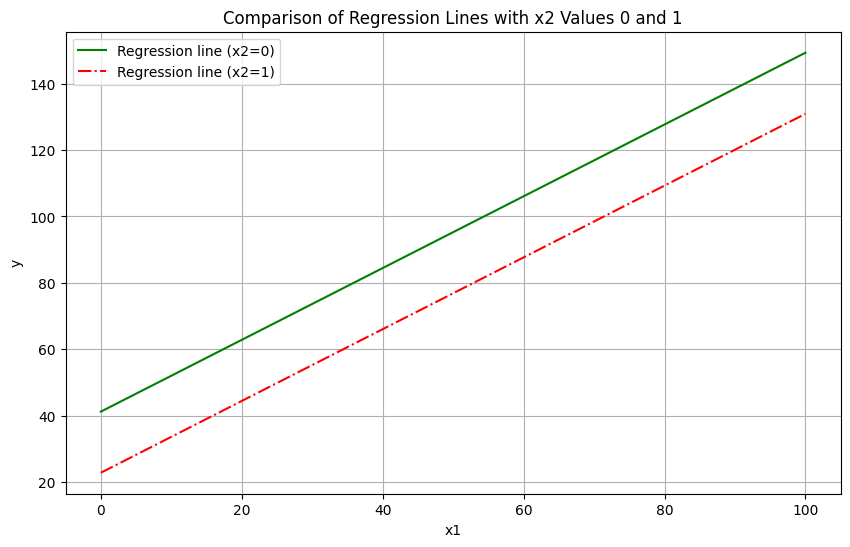

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Given coefficients from regression output
intercept = 41.225
coef_x1 = 1.081
coef_x2 = -18.404

# Defining the range for x1 values after sequence correction
min_x1 = 0
max_x1 = 100
x1_values = np.linspace(min_x1, max_x1, 100)

# Calculating y values for both scenarios: x2 = 0 and x2 = 1
y_x2_0 = intercept + coef_x1 * x1_values
y_x2_1 = intercept + coef_x1 * x1_values + coef_x2 * 1  # Considering x2 as a dummy variable, multiplied by 1

# Plotting the regression lines
plt.figure(figsize=(10, 6))

# Regression line when x2 is 0
plt.plot(x1_values, y_x2_0, label='Regression line (x2=0)', color = 'green')

# Regression line when x2 is 1
plt.plot(x1_values, y_x2_1, label='Regression line (x2=1)', linestyle='-.', color='red')


# Labeling axes
plt.xlabel('x1')
plt.ylabel('y')

# Adding title and legend
plt.title('Comparison of Regression Lines with x2 Values 0 and 1')
plt.legend()

# Displaying the plot with a grid
plt.grid(True)
plt.show()




## Question 3


In [ ]:
import statsmodels.api as sm
# Creating a DataFrame using the given dataset
data = {
    'y': [11, 3, 2, 5, 9, 14, 10, 8, 4, 9, 11, 4, 6, 10, 3, 4, 9, 6],
    'x1': [1.9, 1.6, 2.3, 2, 1.8, 1.9, 2.4, 2.6, 2, 1.4, 1.7, 2.5, 1, 1.4, 1.9, 2.3, 2.2, 1.7],
    'x2': [1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    'x3': [0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0],
    'x4': [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1]
}

# Creating a DataFrame
df = pd.DataFrame(data)

# Adding an intercept column
df['intercept'] = 1

# Performing a multiple regression analysis
X = df[['intercept', 'x1', 'x2', 'x3', 'x4']]
y = df['y']

# Fitting the OLS model
model = sm.OLS(y, X).fit()

# Displaying the regression summary
print(model.summary())



                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     22.33
Date:                Thu, 07 Mar 2024   Prob (F-statistic):           1.00e-05
Time:                        10:44:50   Log-Likelihood:                -28.725
No. Observations:                  18   AIC:                             67.45
Df Residuals:                      13   BIC:                             71.90
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0257      1.734      7.513      0.0

/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


# OLS Regression Analysis Results

The presented output unveils insights derived from an Ordinary Least Squares (OLS) regression model featuring the following attributes:

- **Dependent Variable:** `y`
- **Independent Variables:** `x1`, `x2`, `x3`, `x4`
- **R-squared:** 0.873
- **Adjusted R-squared:** 0.834
- **Number of Observations:** 18

## Interpretation:

- The formidable **R-squared (87.3%)** denotes that a substantial portion of the variance in the dependent variable `y` finds explanation within the model.
- The **Adjusted R-squared (83.4%)**, factoring in the number of predictors, provides a nuanced metric for model comparison.

## Independent Variables:

- **`x1`:** A unit increase in `x1` forecasts a decrease in `y` by 2.4918, holding other variables constant (statistically significant, p < 0.05).
- **`x2`, `x3`, `x4`:** These depict categories of the second independent variable. The positive coefficient for `x2` suggests a positive effect on `y`, while `x3` and `x4` indicate negative effects.

## Dummy Variables:

- The indicator variable encompasses **4 categories** in total, with `x1` serving as the reference.
- **p-values** for `x2`, `x3`, and `x4` assert their statistical significance as predictors of `y`, except for `x4` which is marginally significant (p = 0.013).

## Model Fit:

- A substantial **F-statistic** with a low probability (1.00e-05) underscores the model's excellence in capturing the data.
- The **Durbin-Watson** statistic (2.131) suggests the absence of serious autocorrelation in residuals.

## Assumptions Checking:

- **Omnibus (5.013) and Prob(Omnibus) (0.082):** Residuals might deviate from normality, though the p-value exceeds 0.05.
- **Skewness (-0.626):** Residual distribution may exhibit a slight leftward skew.
- **Kurtosis (4.377):** Residual tails could be heavier than a normal distribution (leptokurtic).
- **Jarque-Bera (JB) and Prob(JB):** Normality tests yield a JB value of 2.599 and a p-value of 0.273, failing to reject the null hypothesis at the 5% level.
- The **Condition Number (13.2):** Signals a moderate level of multicollinearity, generally not alarming.

In conclusion, the model showcases strong predictive capabilities with significant variables. However, the assumption of normally distributed residuals warrants further exploration through residual plots and additional diagnostics beyond the provided output.
